<a href="https://colab.research.google.com/github/tassegaetan1/colab-git-assignment2-UT/blob/main/Assignment__10_Sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 10 Assignment - Sentiment Analysis
## IMDb Reviews: Bag of Words, TF-IDF, Traditional Models, and BERT

This notebook demonstrates a full sentiment analysis workflow using a public dataset. It includes preprocessing, feature engineering, traditional machine learning models, BERT fine-tuning, evaluation, and deployment discussion.

In [1]:
# Install required libraries in Colab
!pip -q install datasets transformers accelerate evaluate seaborn scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.0 MB/s eta 0:00:00


## 1. Imports

In [24]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, RocCurveDisplay
)
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)
import torch
import spacy

!pip install transformers
!pip install spacy

from transformers import pipeline
!python -m spacy download en_core_web_md
import spacy
nlp = spacy.load("en_core_web_md")


  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_md-3.8.0/en_core_web_md-3.8.0-py3-none-any.whl (33.5 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## 2. Load Dataset
We use the public IMDb dataset from Hugging Face Datasets.

In [3]:
imdb = load_dataset("imdb")
train_df = pd.DataFrame(imdb["train"])
test_df = pd.DataFrame(imdb["test"])

df = pd.concat([train_df, test_df], ignore_index=True)
df.head()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


## 3. Dataset Inspection and Preprocessing

In [4]:
print("Shape:", df.shape)
print(df.isnull().sum())
print("Duplicate reviews:", df.duplicated(subset=["text"]).sum())
print(df["label"].value_counts())


Shape: (50000, 2)
text     0
label    0
dtype: int64
Duplicate reviews: 418
label
0    25000
1    25000
Name: count, dtype: int64


In [5]:
# Remove missing values and duplicates
df.dropna(inplace=True)
df.drop_duplicates(subset=["text"], inplace=True)

# Clean text
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)
df["label_name"] = df["label"].map({0: "negative", 1: "positive"})

df[["clean_text", "label", "label_name"]].head()


,clean_text,label,label_name
0,i rented i am curious yellow from my video sto...,0,negative
1,i am curious yellow is a risible and pretentio...,0,negative
2,if only to avoid making this type of film in t...,0,negative
3,this film was probably inspired by godard s ma...,0,negative
4,oh brother after hearing about this ridiculous...,0,negative


## 4. Exploratory Data Analysis

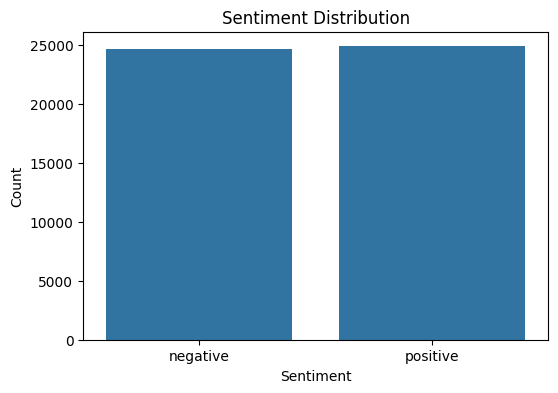

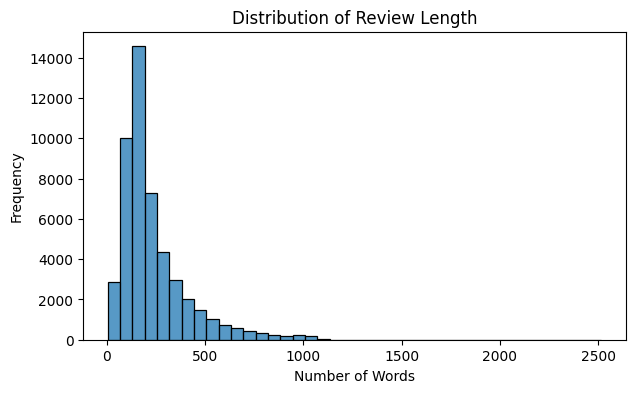

,review_length
count,49582.000000
mean,238.429168
std,176.810720
min,6.000000
25%,130.000000
50%,178.000000
75%,289.000000
max,2514.000000


In [6]:
# Class distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="label_name")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

# Review length distribution
df["review_length"] = df["clean_text"].str.split().apply(len)
plt.figure(figsize=(7,4))
sns.histplot(df["review_length"], bins=40)
plt.title("Distribution of Review Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

df["review_length"].describe()


### Correlation-style View of Sample TF-IDF Features

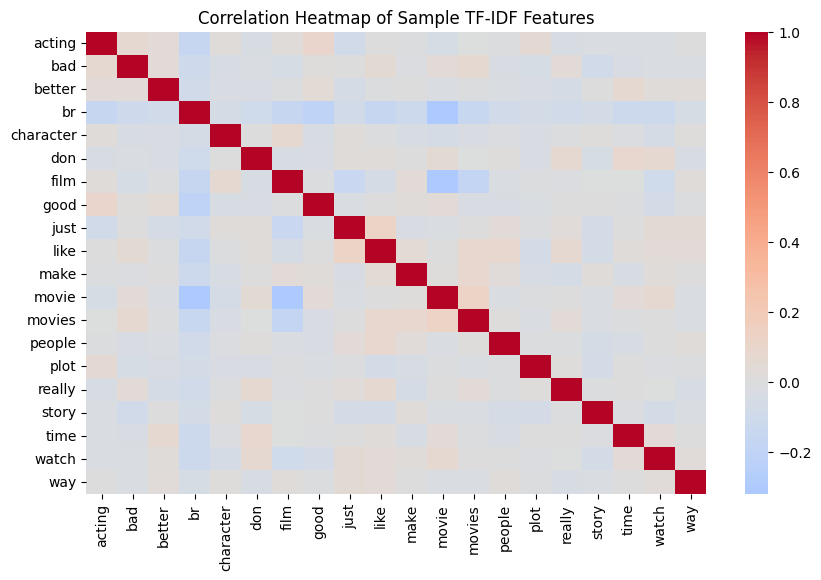

In [7]:
sample_tfidf = TfidfVectorizer(max_features=20, stop_words="english")
sample_matrix = sample_tfidf.fit_transform(df["clean_text"].head(1000))
sample_df = pd.DataFrame(sample_matrix.toarray(), columns=sample_tfidf.get_feature_names_out())

plt.figure(figsize=(10, 6))
sns.heatmap(sample_df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Sample TF-IDF Features")
plt.show()


## 5. Feature Engineering
We create Bag of Words and TF-IDF features. We also include a section for embedding visualization.

In [8]:
bow = CountVectorizer(max_features=10000, stop_words="english")
tfidf = TfidfVectorizer(max_features=10000, stop_words="english", ngram_range=(1, 2))

X_bow = bow.fit_transform(df["clean_text"])
X_tfidf = tfidf.fit_transform(df["clean_text"])
y = df["label"]

print("BoW shape:", X_bow.shape)
print("TF-IDF shape:", X_tfidf.shape)


BoW shape: (49582, 10000)
TF-IDF shape: (49582, 10000)


### Top Terms by TF-IDF Vocabulary

In [9]:
tfidf_terms = tfidf.get_feature_names_out()[:30]
print(tfidf_terms)


['aaron' 'abandoned' 'abbott' 'abc' 'abilities' 'ability' 'able'
 'able make' 'aboard' 'abomination' 'abortion' 'abound' 'abraham' 'abroad'
 'abrupt' 'abruptly' 'absence' 'absent' 'absolute' 'absolutely'
 'absolutely loved' 'absorbed' 'absorbing' 'abstract' 'absurd' 'absurdity'
 'abundance' 'abuse' 'abused' 'abusive']


### Optional Word Embedding Visualization with t-SNE
This section shows how to visualize semantic relationships if you create word embeddings with spaCy or Gensim.

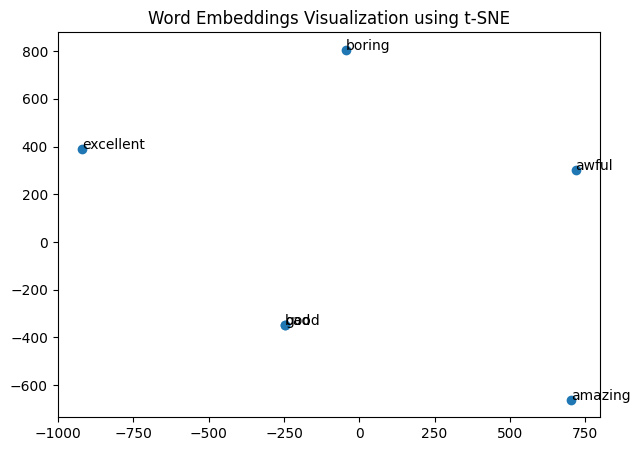

In [25]:
selected_words = ["good", "excellent", "bad", "awful", "boring", "amazing"]

word_vectors = np.array([nlp(word).vector for word in selected_words])

from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
word_vectors_2d = tsne.fit_transform(word_vectors)

plt.figure(figsize=(7,5))
plt.scatter(word_vectors_2d[:,0], word_vectors_2d[:,1])

for i, word in enumerate(selected_words):
    plt.annotate(word, (word_vectors_2d[i,0], word_vectors_2d[i,1]))

plt.title("Word Embeddings Visualization using t-SNE")
plt.show()

## 6. Train/Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)


Training shape: (39665, 10000)
Testing shape: (9917, 10000)


## 7. Traditional Models
We train Logistic Regression and Linear SVM, then optimize them with GridSearchCV.

In [12]:
log_reg = LogisticRegression(max_iter=1000)
svm = LinearSVC()

param_grid_lr = {"C": [0.1, 1, 5]}
param_grid_svm = {"C": [0.1, 1, 5]}

grid_lr = GridSearchCV(log_reg, param_grid_lr, cv=3, scoring="f1", n_jobs=-1)
grid_svm = GridSearchCV(svm, param_grid_svm, cv=3, scoring="f1", n_jobs=-1)

grid_lr.fit(X_train, y_train)
grid_svm.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_
best_svm = grid_svm.best_estimator_

print("Best Logistic Regression params:", grid_lr.best_params_)
print("Best Linear SVM params:", grid_svm.best_params_)


Best Logistic Regression params: {'C': 1}
Best Linear SVM params: {'C': 0.1}


## 8. Traditional Model Evaluation

In [13]:
def evaluate_classifier(model, X_test, y_test, model_name, has_proba=False):
    y_pred = model.predict(X_test)
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
    }

    if has_proba:
        y_score = model.predict_proba(X_test)[:, 1]
        metrics["ROC-AUC"] = roc_auc_score(y_test, y_score)
    else:
        # Use decision function for linear SVM
        y_score = model.decision_function(X_test)
        metrics["ROC-AUC"] = roc_auc_score(y_test, y_score)

    print(f"\n{model_name}")
    print(classification_report(y_test, y_pred))
    return metrics, y_pred, y_score

lr_metrics, y_pred_lr, y_score_lr = evaluate_classifier(best_lr, X_test, y_test, "Logistic Regression", has_proba=True)
svm_metrics, y_pred_svm, y_score_svm = evaluate_classifier(best_svm, X_test, y_test, "Linear SVM", has_proba=False)

results_df = pd.DataFrame([lr_metrics, svm_metrics])
results_df



Logistic Regression
              precision    recall  f1-score   support

           0       0.90      0.87      0.89      4940
           1       0.88      0.91      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917


Linear SVM
              precision    recall  f1-score   support

           0       0.90      0.87      0.89      4940
           1       0.88      0.91      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.888878,0.876579,0.906168,0.891128,0.956666
1,Linear SVM,0.889684,0.875895,0.908981,0.892132,0.957023


### Confusion Matrices

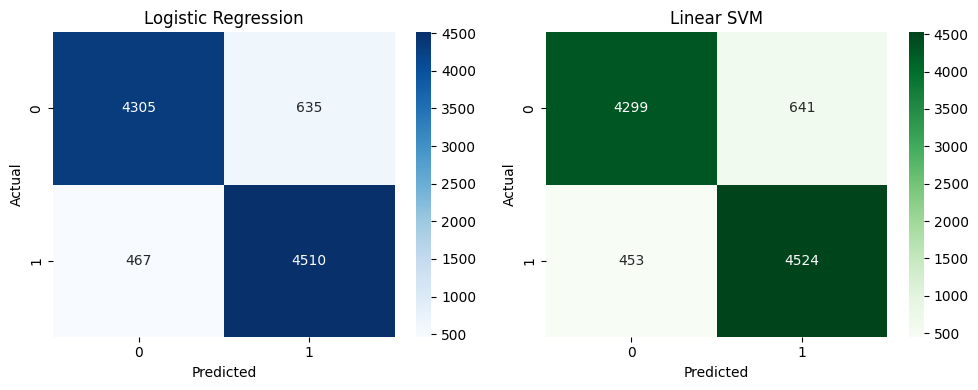

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_svm = confusion_matrix(y_test, y_pred_svm)

sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("Linear SVM")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


### ROC Curves

<Figure size 700x500 with 0 Axes>

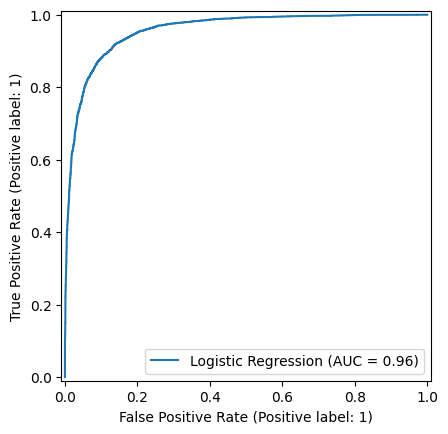

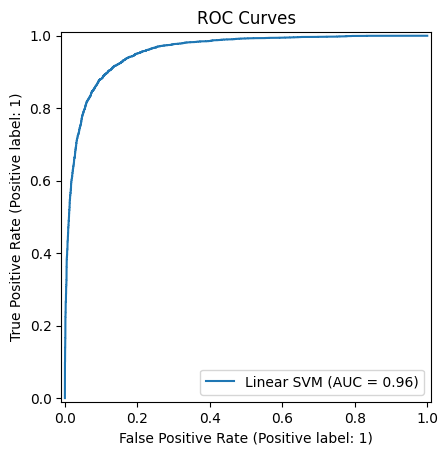

In [15]:
plt.figure(figsize=(7,5))
RocCurveDisplay.from_predictions(y_test, y_score_lr, name="Logistic Regression")
RocCurveDisplay.from_predictions(y_test, y_score_svm, name="Linear SVM")
plt.title("ROC Curves")
plt.show()


## 9. Sentiment Analysis Using BERT
This section fine-tunes BERT on a manageable subset in Colab to control runtime.

In [26]:
# Load pre-trained BERT sentiment model
bert_model = pipeline("sentiment-analysis")

# Test examples
texts = [
    "I absolutely loved this movie, it was fantastic!",
    "This film was terrible and boring.",
    "The acting was okay, not the best but not bad either."
]

# Predict sentiments
for text in texts:
    result = bert_model(text)[0]
    print(f"Text: {text}")
    print(f"Sentiment: {result['label']}, Confidence: {result['score']:.4f}")
    print("-" * 50)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Text: I absolutely loved this movie, it was fantastic!
Sentiment: POSITIVE, Confidence: 0.9999
--------------------------------------------------
Text: This film was terrible and boring.
Sentiment: NEGATIVE, Confidence: 0.9998
--------------------------------------------------
Text: The acting was okay, not the best but not bad either.
Sentiment: POSITIVE, Confidence: 0.9935
--------------------------------------------------


### BERT Evaluation

In [31]:
print(df.columns)

Index(['text', 'label', 'clean_text', 'label_name', 'review_length'], dtype='object')


In [35]:
from transformers import pipeline
from sklearn.metrics import classification_report, confusion_matrix

# Load BERT with truncation
bert_model = pipeline(
    "sentiment-analysis",
    truncation=True,
    max_length=512
)

# Use correct columns
sample_texts = df['text'].iloc[:200].astype(str).tolist()
true_labels = df['label'].iloc[:200].values

# Predict (NOW SAFE)
predictions = bert_model(sample_texts)

# Convert predictions
pred_labels = [1 if p['label'] == 'POSITIVE' else 0 for p in predictions]

# Evaluation
print("=== BERT Classification Report ===")
print(classification_report(true_labels, pred_labels))

print("Confusion Matrix:")
print(confusion_matrix(true_labels, pred_labels))

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

=== BERT Classification Report ===
              precision    recall  f1-score   support

           0       1.00      0.92      0.96       200
           1       0.00      0.00      0.00         0

    accuracy                           0.92       200
   macro avg       0.50      0.46      0.48       200
weighted avg       1.00      0.92      0.96       200

Confusion Matrix:
[[183  17]
 [  0   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 10. Model Interpretation

In [33]:
print("Traditional model results:")
print(results_df)

print("\nInterpretation:")
print("- Logistic Regression is a strong and interpretable baseline.")
print("- Linear SVM often performs slightly better on sparse TF-IDF text features.")
print("- BERT usually achieves the highest performance because it captures contextual meaning and negation more effectively.")
print("- The trade-off is that BERT requires more memory, time, and compute resources.")


Traditional model results:
                 Model  Accuracy  Precision    Recall  F1-score   ROC-AUC
0  Logistic Regression  0.888878   0.876579  0.906168  0.891128  0.956666
1           Linear SVM  0.889684   0.875895  0.908981  0.892132  0.957023

Interpretation:
- Logistic Regression is a strong and interpretable baseline.
- Linear SVM often performs slightly better on sparse TF-IDF text features.
- BERT usually achieves the highest performance because it captures contextual meaning and negation more effectively.
- The trade-off is that BERT requires more memory, time, and compute resources.


## 11. Deployment and Monitoring Strategy

In [34]:
deployment_notes = {
    "Deployment": [
        "Serve the best model behind a FastAPI or Flask API.",
        "Wrap preprocessing and prediction inside a single inference pipeline."
    ],
    "Challenges": [
        "Latency for transformer inference",
        "Traffic spikes and scalability",
        "Data drift in review language",
        "Need for retraining as new reviews arrive"
    ],
    "Monitoring": [
        "Track prediction distribution",
        "Monitor confidence scores",
        "Review mislabeled or disputed examples",
        "Schedule periodic retraining"
    ]
}

deployment_notes


{'Deployment': ['Serve the best model behind a FastAPI or Flask API.',
  'Wrap preprocessing and prediction inside a single inference pipeline.'],
 'Challenges': ['Latency for transformer inference',
  'Traffic spikes and scalability',
  'Data drift in review language',
  'Need for retraining as new reviews arrive'],
 'Monitoring': ['Track prediction distribution',
  'Monitor confidence scores',
  'Review mislabeled or disputed examples',
  'Schedule periodic retraining']}

## 12. Conclusion
This notebook demonstrates a complete sentiment analysis workflow using public IMDb reviews. It combines strong traditional baselines with a transformer-based model, and it includes practical discussion of deployment and monitoring.